For Best Model - **CLIPZeroShot_ViT-L/14_linearLayer**
*   num_classes = 4
*   batch_size = 32
*   max_epochs = 200
*   patience = 50
*   seed = 142



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import shutil
shutil.copytree(
    '/content/drive/MyDrive/CRP_dataset',
    'CRP_dataset'
)

'CRP_dataset'

In [ ]:
pip install git+https://github.com/openai/CLIP.git

In [4]:
import clip
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import numpy as np
import random
import os
import clip_vit
import importlib
from dataload import CustomImageDataset
from sklearn.model_selection import StratifiedShuffleSplit
import time
import csv
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

In [5]:
def plot_curves(train_accs, val_accs, train_losses, seed):
    epochs = range(1, len(train_accs) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
    # Accuracy
    ax1.plot(epochs, train_accs, label='Train Accuracy')
    ax1.plot(epochs, val_accs, label='Validation Accuracy')
    ax1.set_title(f'Accuracy Curves (Seed {seed})')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)
    # Loss
    ax2.plot(train_losses, label='Train Loss')
    ax2.set_title(f'Training Loss (Seed {seed})')
    ax2.set_xlabel('Iterations')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)
    plt.tight_layout()
    plt.savefig(f'curves_seed_{seed}.png', dpi=150)
    plt.show()

In [6]:
def plot_confusion_matrix(all_labels, all_preds, class_names, seed):
    cm = confusion_matrix(all_labels, all_preds)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
    # Raw counts
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax1
    )
    ax1.set_title(f'Confusion Matrix Counts (Seed {seed})')
    ax1.set_xlabel('Predicted')
    ax1.set_ylabel('True')
    # Percentages
    sns.heatmap(
        cm_pct,
        annot=True,
        fmt='.1f',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax2
    )
    ax2.set_title(f'Confusion Matrix % (Seed {seed})')
    ax2.set_xlabel('Predicted')
    ax2.set_ylabel('True')
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_seed_{seed}.png', dpi=150)
    plt.show()

In [7]:
def plot_roc_curve(all_labels, all_probs, class_names, seed):
    labels_bin = label_binarize(
        all_labels,
        classes=np.arange(len(class_names))
    )
    plt.figure(figsize=(8,8))
    for i in range(len(class_names)):
        fpr, tpr, _ = roc_curve(
            labels_bin[:, i],
            np.array(all_probs)[:, i]
        )
        roc_auc = auc(fpr, tpr)
        plt.plot(
            fpr,
            tpr,
            label=f'{class_names[i]} (AUC = {roc_auc:.2f})'
        )
    plt.plot([0,1], [0,1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve (Seed {seed})")
    plt.legend()
    plt.grid(True)
    plt.savefig(f'roc_curve_seed_{seed}.png', dpi=150)
    plt.show()

In [8]:
# CLIP has its own preprocessor (resize, normalize, etc.) — replaces transforms.Compose
_, clip_preprocess = clip.load("ViT-L/14", device="cpu")

100%|███████████████████████████████████████| 890M/890M [00:21<00:00, 43.2MiB/s]


In [9]:
dataset_full = CustomImageDataset("CRP_dataset/crp_iphone/full", transform=clip_preprocess)
labels = [dataset_full.preprocessed_data[path]['label'] for path in dataset_full.samples]

class_names = sorted(os.listdir("CRP_dataset/crp_iphone/full"))
print("Classes found:", class_names)

Starting load Dataset: CRP_dataset/crp_iphone/full
Already loaded 100 images
Already loaded 200 images
Already loaded 300 images
Dataset load complete all 399 images
Classes found: ['190', '2800', '3300', '560']


In [10]:
num_classes = 4
batch_size = 32
max_epochs = 200
patience = 50
repeats = 1

In [11]:
importlib.reload(clip_vit)
from clip_vit import CLIPZeroShotModel

Seed: 142


Epoch 1: Train Acc=0.3013 | Val Acc=0.3000
Epoch 11: Train Acc=0.4226 | Val Acc=0.4375
Epoch 21: Train Acc=0.4686 | Val Acc=0.4750
Epoch 31: Train Acc=0.5230 | Val Acc=0.5250
Epoch 41: Train Acc=0.5690 | Val Acc=0.5750
Epoch 51: Train Acc=0.6025 | Val Acc=0.6250
Epoch 61: Train Acc=0.6276 | Val Acc=0.6500
Epoch 71: Train Acc=0.6653 | Val Acc=0.6750
Epoch 81: Train Acc=0.7029 | Val Acc=0.7500
Epoch 91: Train Acc=0.7029 | Val Acc=0.7500
Epoch 101: Train Acc=0.7029 | Val Acc=0.7625
Epoch 111: Train Acc=0.7071 | Val Acc=0.7625
Epoch 121: Train Acc=0.7197 | Val Acc=0.8000
Epoch 131: Train Acc=0.7238 | Val Acc=0.8000
Epoch 141: Train Acc=0.7197 | Val Acc=0.8000
Epoch 151: Train Acc=0.7238 | Val Acc=0.7875
Epoch 161: Train Acc=0.7280 | Val Acc=0.7875
Early stopping at epoch 169, best val acc 0.8000
Loading best model from best_model_seed_142.pt for testing
Seed 142: Test Acc = 0.7375

Results saved to training_results.csv


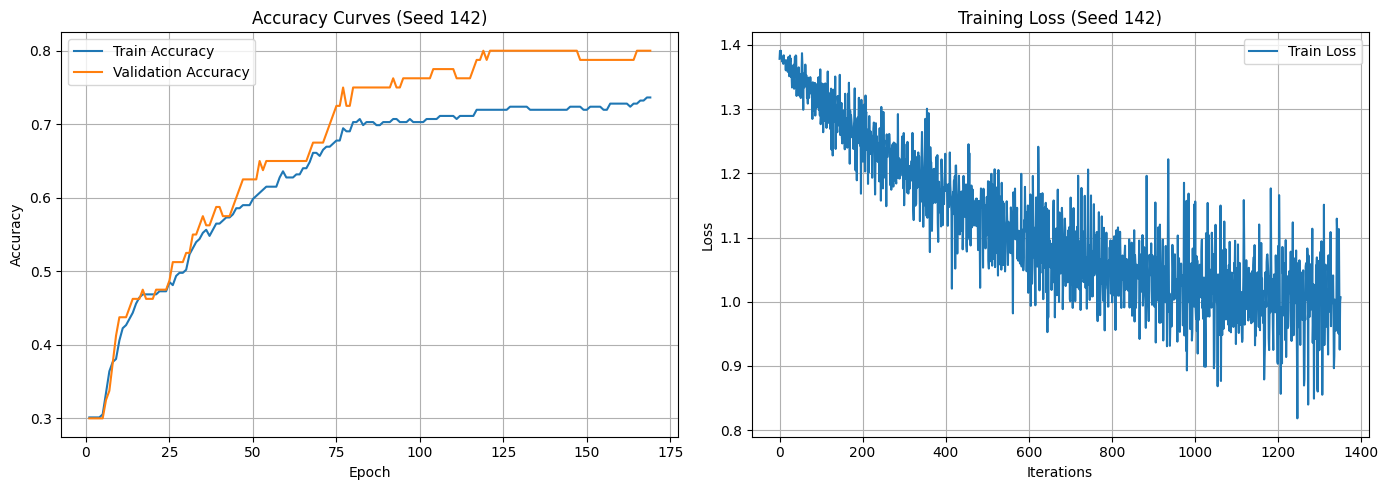

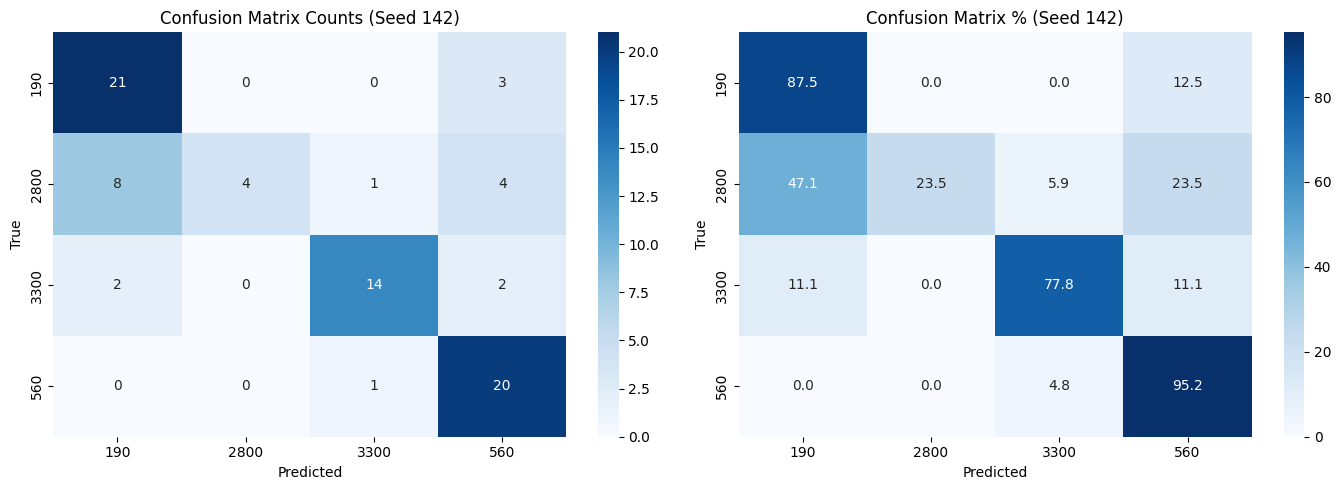

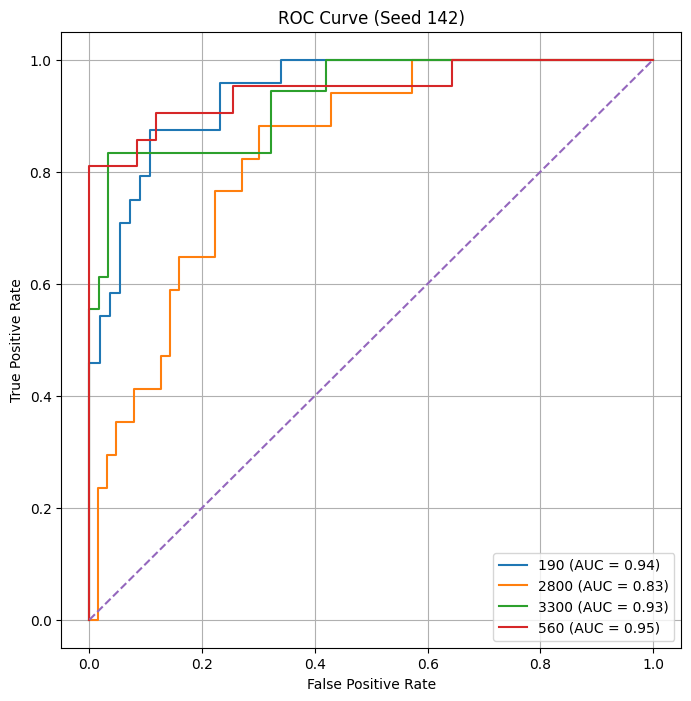


Classification Report:

              precision    recall  f1-score   support

         190       0.68      0.88      0.76        24
        2800       1.00      0.24      0.38        17
        3300       0.88      0.78      0.82        18
         560       0.69      0.95      0.80        21

    accuracy                           0.74        80
   macro avg       0.81      0.71      0.69        80
weighted avg       0.79      0.74      0.71        80



In [12]:
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def train_once(seed, dataset_full, labels):
    print(f'Seed: {seed}\n\n')
    seed_everything(seed)
    start_time = time.time()                          # track time from start

    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.4, random_state=seed)
    for train_idx, test_val_idx in sss.split(np.zeros(len(labels)), labels):
        temp_labels = [labels[i] for i in test_val_idx]
        sss_val = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=seed)
        for val_idx_rel, test_idx_rel in sss_val.split(np.zeros(len(temp_labels)), temp_labels):
            val_idx = [test_val_idx[i] for i in val_idx_rel]
            test_idx = [test_val_idx[i] for i in test_idx_rel]

    train_loader = DataLoader(Subset(dataset_full, train_idx), batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(Subset(dataset_full, val_idx),   batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(Subset(dataset_full, test_idx),  batch_size=batch_size, shuffle=False)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = CLIPZeroShotModel(
        class_names=class_names,
        clip_model_name="ViT-L/14"
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.classifier.parameters(), lr=5e-4, weight_decay=1e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)

    best_acc  = 0
    counter   = 0
    train_acc = 0
    best_model_path = f"best_model_seed_{seed}.pt"

    train_acc_history = []
    val_acc_history   = []
    train_loss_history = []

    for epoch in range(max_epochs):
        # --- Training ---
        model.train()
        epoch_correct, epoch_total = 0, 0
        for images, label, _ in train_loader:
            optimizer.zero_grad()
            outputs = model(images.to(device))
            loss = criterion(outputs, label.to(device))
            loss.backward()
            optimizer.step()
            train_loss_history.append(loss.item())
            _, predicted = torch.max(outputs, 1)
            epoch_total   += label.size(0)
            epoch_correct += (predicted == label.to(device)).sum().item()
        scheduler.step()
        train_acc = epoch_correct / epoch_total
        train_acc_history.append(train_acc)

        # --- Validation ---
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, label, _ in val_loader:
                outputs = model(images.to(device))
                _, predicted = torch.max(outputs, 1)
                total   += label.size(0)
                correct += (predicted == label.to(device)).sum().item()
        acc = correct / total
        val_acc_history.append(acc)
        if epoch%10 == 0:
            print(f"Epoch {epoch+1}: Train Acc={train_acc:.4f} | Val Acc={acc:.4f}")

        if acc > best_acc:
            best_acc = acc
            counter  = 0
            torch.save(model.state_dict(), best_model_path)
        else:
            counter += 1

        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}, best val acc {best_acc:.4f}")
            break

    # --- Test ---
    print(f"Loading best model from {best_model_path} for testing")
    model.load_state_dict(torch.load(best_model_path))
    model.eval()
    correct, total = 0, 0
    all_labels = []
    all_preds = []
    all_probs = []
    with torch.no_grad():
        for images, label, _ in test_loader:
            outputs = model(images.to(device))
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            total   += label.size(0)
            correct += (predicted == label.to(device)).sum().item()
            all_labels.extend(label.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    test_acc = correct / total
    print(f"Seed {seed}: Test Acc = {test_acc:.4f}\n")

    # --- Save to CSV ---
    elapsed_minutes = (time.time() - start_time) / 60
    results_path = "training_results.csv"
    file_exists  = os.path.isfile(results_path)
    with open(results_path, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=["model", "seed", "train_acc", "val_acc", "test_acc", "time_min"])
        if not file_exists:
            writer.writeheader()
        writer.writerow({
            "model":     "CLIPZeroShot_ViT-L/14_linearLayer",
            "seed":      seed,
            "train_acc": round(train_acc, 4),
            "val_acc":   round(best_acc, 4),
            "test_acc":  round(test_acc, 4),
            "time_min":  round(elapsed_minutes, 2)
        })
    print(f"Results saved to {results_path}")

    plot_curves(
        train_acc_history,
        val_acc_history,
        train_loss_history,
        seed
    )
    plot_confusion_matrix(
        all_labels,
        all_preds,
        class_names,
        seed
    )

    plot_roc_curve(
        all_labels,
        all_probs,
        class_names,
        seed
    )

    print("\nClassification Report:\n")

    print(
        classification_report(
            all_labels,
            all_preds,
            target_names=class_names
        )
    )

    return {
      "model_path": best_model_path,
      "train_acc_history": train_acc_history,
      "val_acc_history": val_acc_history,
      "train_loss_history": train_loss_history,
      "test_loader": test_loader
    }

for repeat in range(repeats):
    seed = 142
    results = train_once(seed, dataset_full, labels)